### This notebook provides the methodology used in order to select relevant features for models training and comparison, analysis and observations of trained models.

## Data Loading & Initial Inspection

### Importing the dataset

In [117]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
api = KaggleApi()
api.authenticate()

if not os.path.exists("../datasets/Students Social Media Addiction.csv"):
    api.dataset_download_files(
        "zahranusratt/student-social-media-addiction-analysis-dataset",
        path="../datasets",
        unzip=True
    )
else:
    print("dataset already on local files")

csv_file = os.path.join("../datasets","Students Social Media Addiction.csv")
whole_df = pd.read_csv(csv_file)

print("dataset ready to use")

dataset already on local files
dataset ready to use


### Remembering the dataset

[Student Social Media Addiction Analysis Dataset](https://www.kaggle.com/datasets/zahranusratt/student-social-media-addiction-analysis-dataset)

| Column Name                    | Type                 | Description                                                                  |
| ------------------------------ | -------------------- | ---------------------------------------------------------------------------- |
| Age                          | Numerical            | Age of the student (in years)                                                |
| Gender                       | Categorical          | Gender of the student (e.g., Male, Female)                                   |
| Academic_Level               | Categorical          | Education level (e.g., High School, Undergraduate, Postgraduate)             |
| Country                      | Categorical          | Country of residence of the student                                          |
| Avg_Daily_Usage_Hours        | Numerical            | Average number of hours spent on social media per day                        |
| Most_Used_Platform           | Categorical          | Primary social media platform used (e.g., Instagram, TikTok)                 |
| Affects_Academic_Performance | Categorical (Yes/No) | Whether social media usage negatively impacts academic performance           |
| Sleep_Hours_Per_Night        | Numerical            | Average number of hours the student sleeps per night                         |
| Mental_Health_Score          | Numerical (scale)    | Self-reported mental well-being score (typically 1–10 scale)                 |
| Relationship_Status          | Categorical          | Student’s relationship status (e.g., Single, In a relationship, Complicated) |
| Conflicts_Over_Social_Media  | Numerical (ordinal)  | Frequency/intensity of conflicts caused by social media use                  |
| Addicted_Score               | Numerical (1–10)     | Composite addiction score derived from a psychometric scale (BSMAS)          |


       Student_ID         Age  Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  \
count  705.000000  705.000000             705.000000             705.000000   
mean   353.000000   20.659574               4.918723               6.868936   
std    203.660256    1.399217               1.257395               1.126848   
min      1.000000   18.000000               1.500000               3.800000   
25%    177.000000   19.000000               4.100000               6.000000   
50%    353.000000   21.000000               4.800000               6.900000   
75%    529.000000   22.000000               5.800000               7.700000   
max    705.000000   24.000000               8.500000               9.600000   

       Mental_Health_Score  Conflicts_Over_Social_Media  Addicted_Score  
count           705.000000                   705.000000      705.000000  
mean              6.226950                     2.849645        6.436879  
std               1.105055                     0.957968        1.5

Text(74.44444444444444, 0.5, 'index')

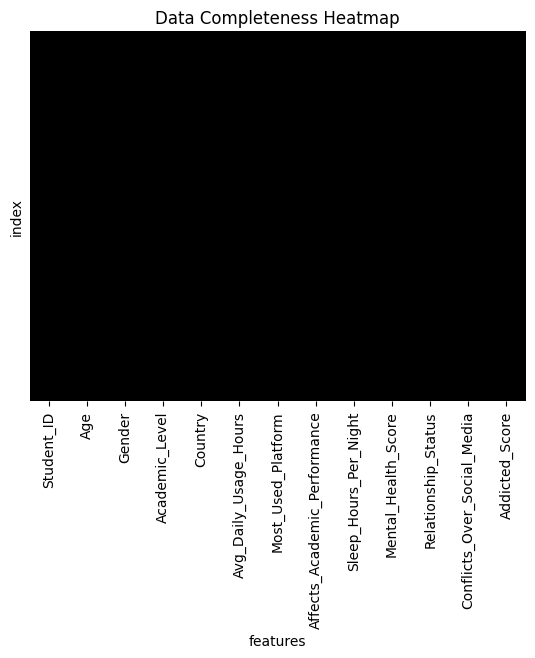

In [118]:
from matplotlib.colors import LinearSegmentedColormap

stats_summary = whole_df.describe()
print(stats_summary)

print("feature number (except Student_ID):", len(whole_df.columns) - 1)
print(whole_df.columns)

colors = ["#000000", "#e74c3c"]
custom_cmap = LinearSegmentedColormap.from_list("bool_map", colors, N=2)
bool_df = whole_df.isnull()
completeness_heatmap = sns.heatmap(bool_df, cmap=custom_cmap, cbar=False, yticklabels=False)
completeness_heatmap.set_title('Data Completeness Heatmap');
completeness_heatmap.set_xlabel('features');
completeness_heatmap.set_ylabel('index')


These outputs shows few metrics about the dataset, such as: basic statistics, valid features, data completeness.
For the completeness heatmap:
- black: not null
- red: null

Which means the dataset has no null values.

You must read [eda.ipynb](eda.ipynb) and [tsne.ipynb](tsne.ipynb) before this one.


### Main objective & methodology

#### Defining Decriptors and target features

The defined target is this notebook will be **Addicted_Score**. Classification will be used to get an **assertive Addicted_Score** using the other features, the **descriptors**. This will be achieved by select features that are relevant to provide an accurate Addiction score based on the data provided by the dataset.

Insights from previous notebooks will be used to recover insights gathered until now, alongside creating new ones to filter even more what will be considered relevant.

e.g.:
- Correlation table
- High-dimensional data simplified with t-SNE
- Deeper analysis based on Addicted_Score

Also, new feature selection techniques will be applied.
e.g.:
- Variable Ranking
- Feature engineering engineering 

#### Performance measurements

The perfomance measurement is used to analyze and compare model's precision using several formulas, it will be used in this notebook to compare the **differences between feature selected vs. non-feature selected models**.

Performance Measurement used throughout this notebook:

| Metric | Description |
|--------|-------------|
| Root Mean Squared Error (RMSE) | Measures the distance between observed and predicted values in a model. Lower values indicate better performance. |
| Accuracy | Percentage of correct predictions made by the model. |
| Precision | Ratio of true positives to all predicted positives (true positives + false positives). |
| Recall | Ratio of true positives to actual positives (true positives + false negatives). |
| F1-Score | Harmonic mean of precision and recall. |
| Support | Number of occurrences of each class in the dataset. |

## Feature selection

### Numerical feature selection

#### Variable Ranking

This section prepares the numerical features in the dataset for ranking using SelectKBest selection method, which filters the features ans assign a score based on Mutual information (MI).

In [119]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
import pandas as pd

# preparing the test: X = predictors, y = target (Addicted_Score)
df_numeric = whole_df.select_dtypes(['number']).drop(columns='Student_ID')
X = df_numeric.drop(columns='Addicted_Score')
y = df_numeric['Addicted_Score']

In [120]:
reg = SelectKBest(mutual_info_classif, k=4).fit(X,y)
# printing the results sorted by score
scores = reg.scores_
feature_scores = pd.DataFrame({
    "feature": X.columns,
    "mutual_info": scores
}).sort_values(by="mutual_info", ascending=False)
print(feature_scores)

selected_features = X.columns[reg.get_support()]
select_k_best_filtered_features_df = X[selected_features]
print("\nSelected features:", selected_features.tolist())

                       feature  mutual_info
3          Mental_Health_Score     1.093425
4  Conflicts_Over_Social_Media     1.049343
1        Avg_Daily_Usage_Hours     0.625622
2        Sleep_Hours_Per_Night     0.507522
0                          Age     0.110249

Selected features: ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Conflicts_Over_Social_Media']


Based on variable ranking, the four most important features are:
1. Mental_Health_Score
2. Conflicts_Over_Social_Media
3. Avg_Daily_Usage_Hours
4. Sleep_Hours_Per_Night

While compared with **Addicted_Score** as the target.

#### Correlation-based ranking

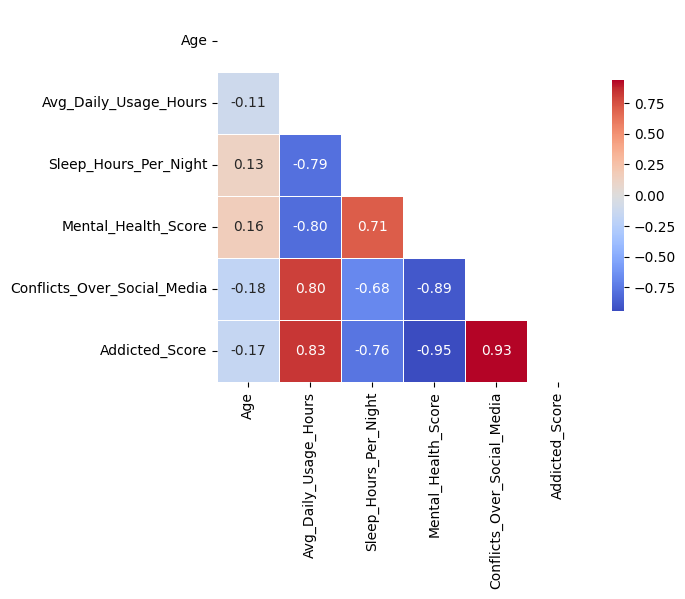

In [121]:
corr_matrix = df_numeric.corr()

plt.figure(figsize=(6, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

Similarly, it's possible to see a corroboration of these values gathered from the SelectKBest's regression.

The correlation are ranked as (in absolute values):
1. Mental_Health_Score
2. Conflicts_Over_Social_Media
3. Avg_Daily_Usage_Hours
4. Sleep_Hours_Per_Night

In [122]:
import pandas as pd
from scipy.stats import spearmanr

# mutual info and correlation scores sorted by column
mi_scores = pd.Series(reg.scores_, index=X.columns)
corr_scores = X.corrwith(y).abs()

# comparison
df_compare = pd.DataFrame({
    "mutual_info": mi_scores,
    "correlation": corr_scores
}).loc[X.columns].sort_values(by="mutual_info", ascending=False)
print(df_compare)

# spearman score
spearman_corr, _ = spearmanr(df_compare["mutual_info"], df_compare["correlation"])
print("Spearman:", spearman_corr)


                             mutual_info  correlation
Mental_Health_Score             1.093425     0.945051
Conflicts_Over_Social_Media     1.049343     0.933586
Avg_Daily_Usage_Hours           0.625622     0.832000
Sleep_Hours_Per_Night           0.507522     0.764858
Age                             0.110249     0.166396
Spearman: 0.9999999999999999


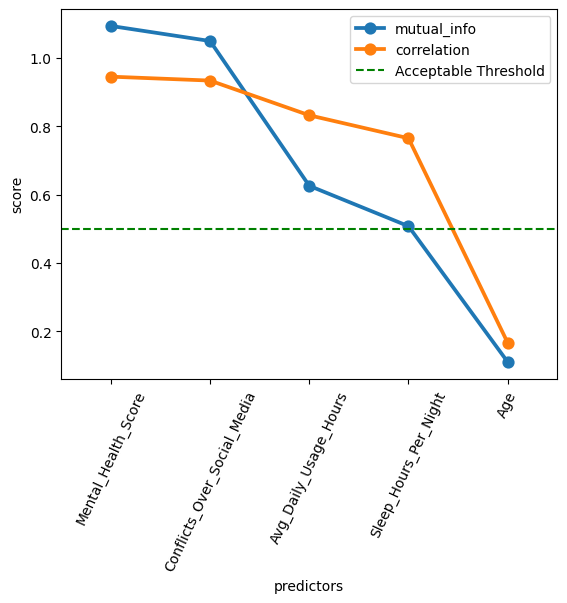

In [123]:
ax0 = sns.pointplot(df_compare['mutual_info'], label='mutual_info')
ax1 = sns.pointplot(df_compare['correlation'], label='correlation')
plt.xticks(rotation=65)
plt.axhline(y=0.5, color='green', linestyle='--', label='Acceptable Threshold')
plt.ylabel("score")
plt.xlabel("predictors")
plt.legend()


[Spearmanr's](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) compares two datasets and measures the monotonicity of the relationship between two datasets. The 0.9+ result cross-validates this corroboration.

## Early model training and predictions

This section presents how different models behave while given selected or not features, and also how dataset limitations affect the training results and prediction.

Machine learning algorithms used:
- XGBoost
- LightGBM
- Random Forest
- ~~SVM Support Vector Machines~~ (still to be implemented)

### Training models using XGBoost

Using this example in order to incorporate numerical and categorical data for training:
[XGBoost's Native Support for Categorical Features](https://xgboosting.com/xgboosts-native-support-for-categorical-features/).

#### First experiment:

1. Loading the dataset  
2. Handling categorical columns  
3. Instantiating a label encoder  
4. Defining predictors and target features  
5. Training the model  
6. Generating new data for prediction  
7. Making prediction  
8. Decoding the label to get the prediction's value  

The input data is just a random dataset csv line, copied without the **Student_ID** and **Addicted_Score** features. Both are highlited in <font color="red">red</font>.

| <font color="red">~~3~~</font>| 20 | Female | Undergraduate | USA | 6.0 | TikTok | Yes | 5.0 | 5 | Complicated | 4 | <font color="red">~~9~~</font> |
|---|---|---|---|---|---|---|---|---|---|---|---|---|

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Load data into a DataFrame
data = whole_df.drop(columns='Student_ID')

# Handling categorical columns
categorical_columns = whole_df.select_dtypes(exclude='number').columns.tolist()

# Convert categorical columns to 'category' data type
for col in categorical_columns:
    # print(col)
    data[col] = data[col].astype('category')

# Instantiating a label encoder
le = LabelEncoder()

# Defining predictors and target features
X = data.drop(columns='Addicted_Score')
y = le.fit_transform(data.Addicted_Score)

# Training the model 
model = XGBClassifier(enable_categorical=True)
model.fit(X, y)

# Generating new data for prediction
new_data = pd.DataFrame(
    [{
        'Age': 20,
        'Gender': 'Female',
        'Academic_Level': 'Undergraduate',
        'Country': 'USA',
        'Avg_Daily_Usage_Hours': 6.0,
        'Most_Used_Platform': 'TikTok',
        'Affects_Academic_Performance': 'Yes',
        'Sleep_Hours_Per_Night': 5.0,
        'Mental_Health_Score': 5,
        'Relationship_Status': 'Complicated',
        'Conflicts_Over_Social_Media': 4
    }]
)

# Convert categorical columns to 'category' data type
for col in categorical_columns:
    new_data[col] = new_data[col].astype('category')

# Making prediction
predictions = model.predict(new_data)
print("encoded label:", predictions)

# Decoding the label to get the prediction's value
predicted_label = le.inverse_transform(predictions)
print("after encoder label transformation:", predicted_label)

encoded label: [7]
after encoder label transformation: [9]


The goal here was to assert if existent data would output the correct target value, **which it did successfully**.

---

#### Without feature selection

Verifying performance measurements:

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# load data into a DataFrame
data = whole_df.drop(columns='Student_ID')
# as this class only appear once, it wasn't possible to split test and training data correctly stratified, so I took it out
data = data[data['Addicted_Score'] != 2]

# specify categorical columns
categorical_columns = whole_df.select_dtypes(exclude='number').columns.tolist()

# print(data.info())
# convert categorical columns to 'category' data type
for col in categorical_columns:
    # print(col)
    data[col] = data[col].astype('category')

# split into features and target
le = LabelEncoder()

X = data.drop(columns='Addicted_Score')
y = le.fit_transform(data.Addicted_Score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model = XGBClassifier(enable_categorical=True)
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

train_pred = model.predict(X_train)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.94      0.94      0.94        17
           2       0.96      0.96      0.96        27
           3       0.92      1.00      0.96        12
           4       1.00      1.00      1.00        42
           5       1.00      1.00      1.00        29
           6       1.00      1.00      1.00        11

    accuracy                           0.98       141
   macro avg       0.98      0.94      0.95       141
weighted avg       0.98      0.98      0.98       141

Train accuracy: 1.0
Test accuracy: 0.9787234042553191


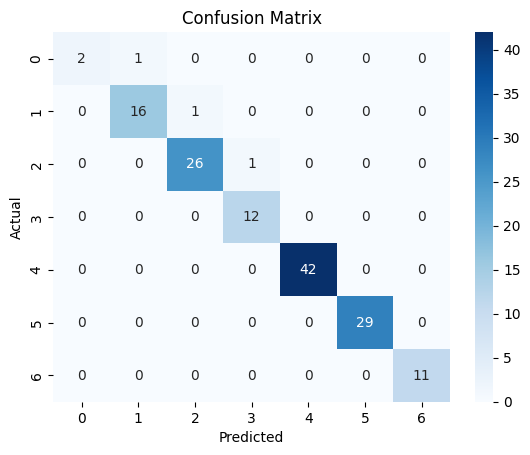

In [126]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### With feature selection

In [127]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder


# Student_ID                    = user ids, no valid insights
# Age                           = least important feature according to correlation matrix, mutual informantion, spearmanr scores
# Mental_Health_Score           = too high score (MI and corr.), could be acting as proxy for evaluating the target
# Conflicts_Over_Social_Media   = too high score (MI and corr.), could be acting as proxy for evaluating the target

# Load data into a DataFrame
drop_cols = [
    'Student_ID',
    'Age', 
    'Mental_Health_Score',
    'Conflicts_Over_Social_Media'
]
data = whole_df.drop(columns=drop_cols)
data = data[data['Addicted_Score'] != 2]

# Specify categorical columns
categorical_columns = whole_df.select_dtypes(exclude='number').columns.tolist()

# print(data.info())
# Convert categorical columns to 'category' data type
for col in categorical_columns:
    # print(col)
    data[col] = data[col].astype('category')

# Split into features and target
le = LabelEncoder()

X = data.drop(columns='Addicted_Score')
y = le.fit_transform(data.Addicted_Score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model = XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    min_child_weight=3,
    enable_categorical=True,
    random_state=42
)
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

train_pred = model.predict(X_train)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9290780141843972
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.94      0.94      0.94        17
           2       0.93      0.96      0.95        27
           3       0.91      0.83      0.87        12
           4       0.97      0.90      0.94        42
           5       0.88      0.97      0.92        29
           6       0.92      1.00      0.96        11

    accuracy                           0.93       141
   macro avg       0.93      0.90      0.91       141
weighted avg       0.93      0.93      0.93       141

Train accuracy: 0.9680284191829485
Test accuracy: 0.9290780141843972


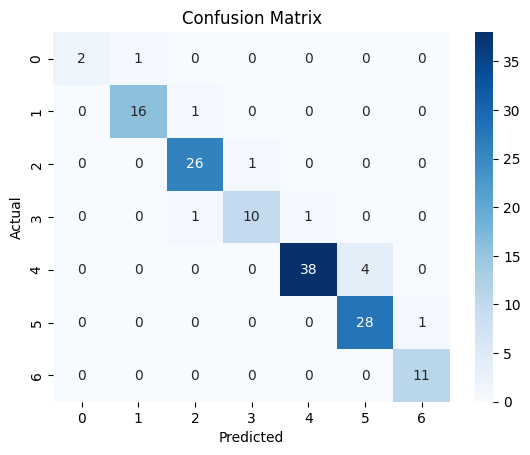

In [128]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Training models using LightGBM

#### Without feature selection

In [129]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score


import lightgbm as lgb

print("Loading data...")
drop_cols = ['Student_ID']
data = whole_df.drop(columns=drop_cols)
data = data[data['Addicted_Score'] != 2]

# Specify categorical columns
categorical_columns = whole_df.select_dtypes(exclude='number').columns.tolist()

# print(data.info())
# Convert categorical columns to 'category' data type
for col in categorical_columns:
    # print(col)
    data[col] = data[col].astype('category')

# Split into features and target
le = LabelEncoder()

X = data.drop(columns='Addicted_Score')
y = le.fit_transform(data.Addicted_Score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Starting training...")
# train
gbm = lgb.LGBMClassifier(
    num_leaves=50,
    learning_rate=0.05,
    n_estimators=200,
    min_data_in_leaf=5,
    random_state=42
)
gbm.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(3)]
)

print("Starting predicting...")
# predict
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)
# eval
rmse_test = mean_squared_error(y_test, y_pred) ** 0.5
print(f"The RMSE of prediction is: {rmse_test}")

# feature importances
print(f"Feature importances: {list(gbm.feature_importances_)}")

print("Accuracy:", accuracy_score(y_test, y_pred))

Loading data...
Starting training...
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000218 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 184
[LightGBM] [Info] Number of data points in the train set: 563, number of used features: 11
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Start training from score -3.768330
[LightGBM] [Info] Start training from score -2.143625
[LightGBM] [Info] Start training from score -1.641932
[LightGBM] [Info] Start training from score -2.441459
[LightGBM] [Info] Start training from score -1.215286
[LightGBM] [Info] Start training from score -1.

In [130]:
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

print("Loading data...")
drop_cols = [
            'Student_ID',
            'Age'
            ]
data = whole_df.drop(columns=drop_cols)
data = data[data['Addicted_Score'] != 2]

# Specify categorical columns
categorical_columns = whole_df.select_dtypes(exclude='number').columns.tolist()

# print(data.info())
# Convert categorical columns to 'category' data type
for col in categorical_columns:
    # print(col)
    data[col] = data[col].astype('category')

# Split into features and target
le = LabelEncoder()

X = data.drop(columns='Addicted_Score')
y = le.fit_transform(data.Addicted_Score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Starting training...")
# train
gbm = lgb.LGBMClassifier(
    num_leaves=50,
    learning_rate=0.05,
    n_estimators=200,
    min_data_in_leaf=5,
    random_state=42
)
gbm.fit(
    X_train,
    y_train,
    categorical_feature=categorical_columns,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(3)]
)

print("Starting predicting...")
# predict
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)
# eval
rmse_test = mean_squared_error(y_test, y_pred) ** 0.5
print(f"The RMSE of prediction is: {rmse_test}")

# feature importances
print(f"Feature importances: {list(gbm.feature_importances_)}")

from sklearn.metrics import classification_report
print(classification_report(y_test, gbm.predict(X_test)))


Loading data...
Starting training...
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000178 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 176
[LightGBM] [Info] Number of data points in the train set: 563, number of used features: 10
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Start training from score -3.768330
[LightGBM] [Info] Start training from score -2.143625
[LightGBM] [Info] Start training from score -1.641932
[LightGBM] [Info] Start training from score -2.441459
[LightGBM] [Info] Start training from score -1.215286
[LightGBM] [Info] Start training from score -1.

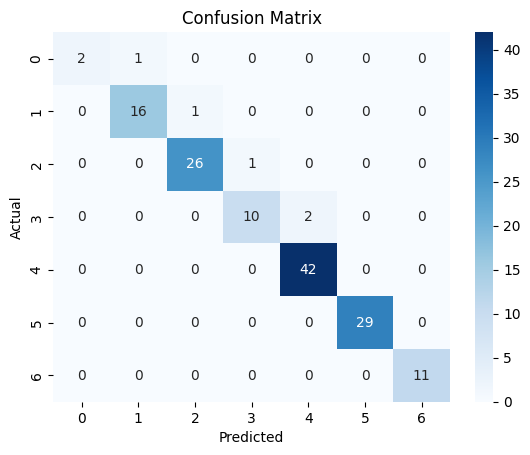

In [131]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### With feature selection

In [132]:
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

print("Loading data...")
drop_cols = [
            'Student_ID',
            'Age', 
            'Mental_Health_Score',
            'Conflicts_Over_Social_Media'
            ]
data = whole_df.drop(columns=drop_cols)
data = data[data['Addicted_Score'] != 2]

# Specify categorical columns
categorical_columns = whole_df.select_dtypes(exclude='number').columns.tolist()

# print(data.info())
# Convert categorical columns to 'category' data type
for col in categorical_columns:
    # print(col)
    data[col] = data[col].astype('category')

# Split into features and target
le = LabelEncoder()

X = data.drop(columns='Addicted_Score')
y = le.fit_transform(data.Addicted_Score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Starting training...")
# train
gbm = lgb.LGBMClassifier(
    num_leaves=50,
    learning_rate=0.05,
    n_estimators=200,
    min_data_in_leaf=5,
    random_state=42
)
gbm.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(10)]
)

print("Starting predicting...")
# predict
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)
# eval
rmse_test = mean_squared_error(y_test, y_pred) ** 0.5
print(f"The RMSE of prediction is: {rmse_test}")

# feature importances
print(f"Feature importances: {list(gbm.feature_importances_)}")

from sklearn.metrics import classification_report
print(classification_report(y_test, gbm.predict(X_test)))


Loading data...
Starting training...
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000147 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 164
[LightGBM] [Info] Number of data points in the train set: 563, number of used features: 8
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Start training from score -3.768330
[LightGBM] [Info] Start training from score -2.143625
[LightGBM] [Info] Start training from score -1.641932
[LightGBM] [Info] Start training from score -2.441459
[LightGBM] [Info] Start training from score -1.215286
[LightGBM] [Info] Start training from score -1.5

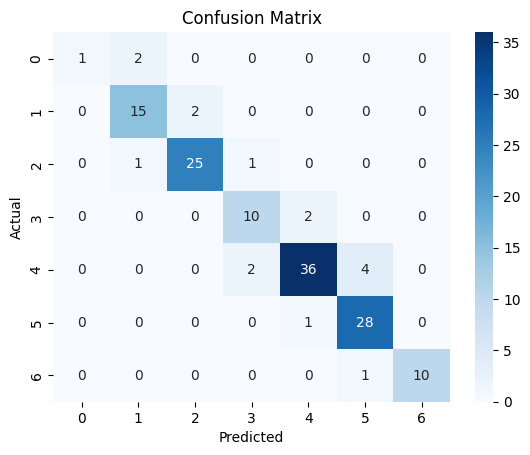

In [133]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Training models using Random Forest

#### Without feature selection

In [134]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# load data into a DataFrame
data = whole_df.drop(columns='Student_ID')
# as this class only appear once, it wasn't possible to split test and training data correctly stratified, so I took it out
data = data[data['Addicted_Score'] != 2]

# specify categorical columns
categorical_columns = data.select_dtypes(exclude='number')
# convert categorical columns to 'category' data type
for col in categorical_columns.columns.tolist():
    # print(col)
    data[col] = data[col].astype('category')

# print(data.info())
# print(categorical_columns.info())

encoder = OneHotEncoder(sparse_output=False)
encoded_data_list = encoder.fit_transform(categorical_columns)
encoded_df = pd.DataFrame(
    encoded_data_list,
    columns=encoder.get_feature_names_out(categorical_columns.columns),
    index=data.index
)

merged_encoded_features = pd.concat([data.drop(columns=categorical_columns.columns), encoded_df], axis=1)
# print(merged_encoded_features.head())
# print(merged_encoded_features.columns.tolist())

# split into features and target

X = merged_encoded_features.drop(columns='Addicted_Score')
y = merged_encoded_features.Addicted_Score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.9787234042553191

Classification Report:
              precision    recall  f1-score   support

           3       1.00      0.67      0.80         3
           4       0.94      0.94      0.94        17
           5       0.96      0.96      0.96        27
           6       0.92      1.00      0.96        12
           7       1.00      1.00      1.00        42
           8       1.00      1.00      1.00        29
           9       1.00      1.00      1.00        11

    accuracy                           0.98       141
   macro avg       0.98      0.94      0.95       141
weighted avg       0.98      0.98      0.98       141



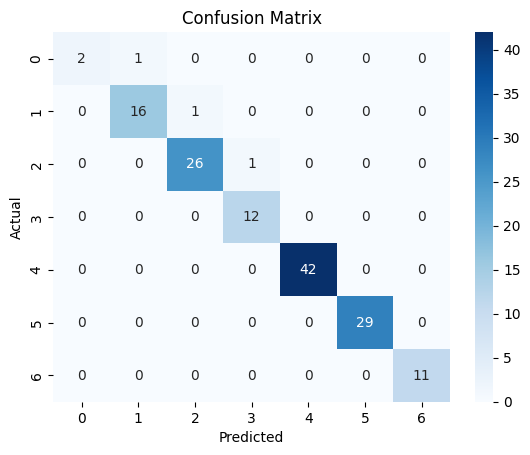

In [135]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### With feature selection

In [136]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

drop_cols = [
            'Age', 
            'Mental_Health_Score',
            'Conflicts_Over_Social_Media'
            ]
# load data into a DataFrame
data = whole_df.drop(columns='Student_ID')
# as this class only appear once, it wasn't possible to split test and training data correctly stratified, so I took it out
data = data[data['Addicted_Score'] != 2]

# specify categorical columns
categorical_columns = data.select_dtypes(exclude='number')
# convert categorical columns to 'category' data type
for col in categorical_columns.columns.tolist():
    # print(col)
    data[col] = data[col].astype('category')

# print(data.info())
# print(categorical_columns.info())

encoder = OneHotEncoder(sparse_output=False)
encoded_data_list = encoder.fit_transform(categorical_columns)
encoded_df = pd.DataFrame(
    encoded_data_list,
    columns=encoder.get_feature_names_out(categorical_columns.columns),
    index=data.index
)

merged_encoded_features = pd.concat([data.drop(columns=categorical_columns.columns), encoded_df], axis=1)
merged_encoded_features = merged_encoded_features.drop(columns=drop_cols)
print(merged_encoded_features.columns.tolist())

# split into features and target

X = merged_encoded_features.drop(columns='Addicted_Score')
y = merged_encoded_features.Addicted_Score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Addicted_Score', 'Gender_Female', 'Gender_Male', 'Academic_Level_Graduate', 'Academic_Level_High School', 'Academic_Level_Undergraduate', 'Country_Afghanistan', 'Country_Albania', 'Country_Andorra', 'Country_Argentina', 'Country_Armenia', 'Country_Australia', 'Country_Austria', 'Country_Azerbaijan', 'Country_Bahamas', 'Country_Bahrain', 'Country_Bangladesh', 'Country_Belarus', 'Country_Belgium', 'Country_Bhutan', 'Country_Bolivia', 'Country_Bosnia', 'Country_Brazil', 'Country_Bulgaria', 'Country_Canada', 'Country_Chile', 'Country_China', 'Country_Colombia', 'Country_Costa Rica', 'Country_Croatia', 'Country_Cyprus', 'Country_Czech Republic', 'Country_Denmark', 'Country_Ecuador', 'Country_Egypt', 'Country_Estonia', 'Country_Finland', 'Country_France', 'Country_Georgia', 'Country_Germany', 'Country_Ghana', 'Country_Greece', 'Country_Hong Kong', 'Country_Hungary', 'Country_Iceland', 'Country_India', 'Country_Indonesia', 'Country_Iraq', 'C

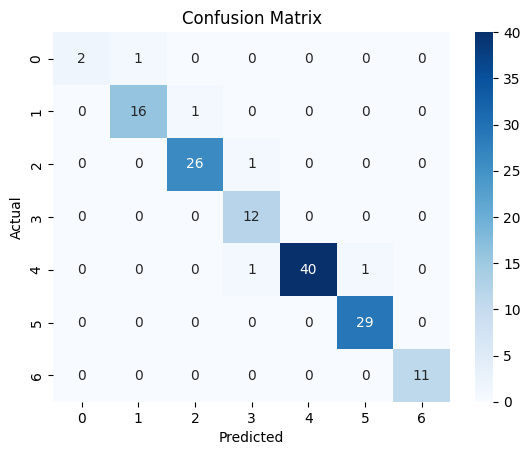

In [137]:
cm = confusion_matrix(y_test, predictions)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Insights and Conclusion *(so far)*

- The predictions seem to be accurate from the training set perspective, reaching about (+-95% accuracy), although there are classes that cannot be asserted due to the lack of observations;
- A whole class needed to be dropped, as there were only one observation, which made it impossible to used stratified database splitting (which Addicted_Score == 2);
- The confusion matrices shows that there are **minor classes overlapping and adjacent mispredictions**;
- Manual feature selection seem to **worsen the accuracy and f1-score**, because tree-based algorithms already ignores not useful features;
- Dropping some features with **both high mutual information and correlation scores did not break predictions**, which can be associated with **robustness** in the model;
    - so far, these numerical features:
    
        | feature | explanation |
        |---|---|
        | Student_ID | user ids, no valid for insights in any way |
        | Age | least important feature according to correlation matrix, mutual informantion, spearmanr scores |
        | Mental_Health_Score | too high score (MI and corr.), could be acting as proxy for evaluating the target |
        | Conflicts_Over_Social_Media | too high score (MI and corr.), could be acting as proxy for evaluating the target |